In [10]:
import numpy as np
import matplotlib.pyplot as plt

import constants
import vertical_profile as vp
import heterostructure_models.dot_3d as d3
import heterostructure_models.dot_2d as d2
import solvers
from matplotlib.colors import Normalize


No alloy disorder

<>:69: SyntaxWarning: invalid escape sequence '\l'
<>:69: SyntaxWarning: invalid escape sequence '\l'
/var/folders/ck/pf24zq5s62x4h9y5sfrmy_z40000gp/T/ipykernel_60854/3345458788.py:69: SyntaxWarning: invalid escape sequence '\l'
  ax[0].text(0.05, 0.26, r"$\langle v_0 | x | v_0 \rangle = $" + f"{x00:0.2f} (nm)", transform=ax[0].transAxes)


Norm v0: 1.0
Norm v1: 1.0


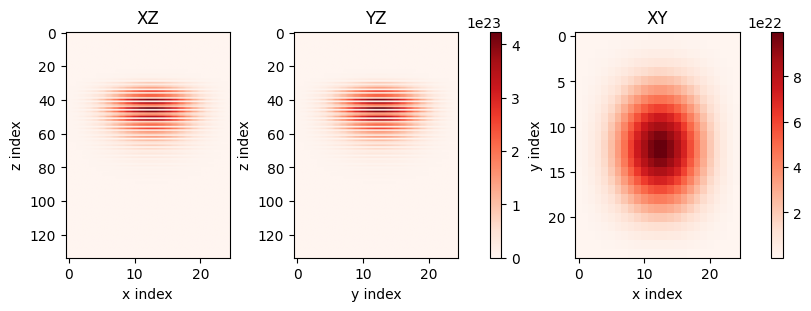

In [11]:
# Sharp vertical profile, so we see the impact of a step on the valley splitting
prof = vp.VerticalProfile(interface_type='sharp', top_cap_width_nm=4, bot_cap_width_nm=4)

d2d = d2.Dot2D(si_concentrations=prof.si_concentrations, step_model='none', nx=25, dx_unit_cells=4)
d3model = d3.Dot3D(step_model=d2d, dy_unit_cells=4, ny=25)
lat3d = d3model.effective_lattice

model_tb = solvers.TwoBand_3D(
    effective_lattice = lat3d, 
    bulk_si_concentration = prof.bot_cap_si_concentration, 
    well_si_concentration = prof.well_si_concentration,
    vertical_field = 0.005,
    dx_nm = d3model.dx_nm,
    dy_nm = d3model.dy_nm
)

evals, evecs = model_tb.solve(n_lowest_eigenstates=2)
v0 = evecs[:,0]
v1 = evecs[:,1]

# Convert vectors v0 and v1 to 2D matrices for viewing
v0 = model_tb.wf_3D_matrix_from_vector(v0)
v1 = model_tb.wf_3D_matrix_from_vector(v1)

# Test normalization
print(f"Norm v0: {np.sum(np.abs(v0)**2 * model_tb.dz * model_tb.dx * model_tb.dy)}")
print(f"Norm v1: {np.sum(np.abs(v1)**2 * model_tb.dz * model_tb.dx * model_tb.dy)}")

# Probability density
density_0 = np.abs(v0)**2
density_1 = np.abs(v1)**2

# Used for plotting
alphas_0 = Normalize(clip=True)(density_0)
alphas_1 = Normalize(clip=True)(density_1)

# Dipolar matrix elements
#x01 = model_tb.x01_nm
#x00 = model_tb.x00_nm
#x11 = model_tb.x11_nm

#z01 = model_tb.z01_nm
#z00 = model_tb.z00_nm
#z11 = model_tb.z11_nm

(nx, ny, nz) = np.shape(density_0)
density_0_xz = np.mean(density_0, axis=1)
density_0_yz = np.mean(density_0, axis=0)
density_0_xy = np.mean(density_0, axis=2)

max_wf = max([np.max(density_0_xz), np.max(density_0_yz), np.max(density_0_xy)])


# Plotting
fig, ax = plt.subplots(1, 3, figsize=(8,3), layout='constrained')

im0 = ax[0].imshow(density_0_xz.T, cmap="Reds",  vmin=0, vmax=max_wf, aspect='auto')
ax[0].set_title('XZ')

im1 = ax[1].imshow(density_0_yz.T, cmap="Reds",  vmin=0, vmax=max_wf, aspect='auto')
fig.colorbar(im1, ax=ax[1])
ax[1].set_title('YZ')

im2 = ax[2].imshow(density_0_xy.T, cmap="Reds", aspect='auto')
fig.colorbar(im2, ax=ax[2])
ax[2].set_title('XY')

"""
ax[0].text(0.05, 0.26, r"$\langle v_0 | x | v_0 \rangle = $" + f"{x00:0.2f} (nm)", transform=ax[0].transAxes)
ax[0].text(0.05, 0.33, r"$\langle v_1 | x | v_1 \rangle = $" + f"{x11:0.2f} (nm)", transform=ax[0].transAxes)
ax[0].text(0.05, 0.4, r"$\langle v_0 | x | v_1 \rangle = $" + f"{x01:0.2f} (nm)", transform=ax[0].transAxes)

ax[1].text(0.05, 0.26, r"$\langle v_0 | z | v_0 \rangle = $" + f"{z00:0.2f} (nm)", transform=ax[1].transAxes)
ax[1].text(0.05, 0.33, r"$\langle v_1 | z | v_1 \rangle = $" + f"{z11:0.2f} (nm)", transform=ax[1].transAxes)
ax[1].text(0.05, 0.4, r"$\langle v_0 | z | v_1 \rangle = $" + f"{z01:0.2f} (nm)", transform=ax[1].transAxes)
"""

ax[0].set_xlabel("x index")
ax[0].set_ylabel("z index")

ax[1].set_xlabel("y index")
ax[1].set_ylabel("z index")

ax[2].set_xlabel("x index")
ax[2].set_ylabel("y index")

plt.show()



With alloy disorder

<>:69: SyntaxWarning: invalid escape sequence '\l'
<>:69: SyntaxWarning: invalid escape sequence '\l'
/var/folders/ck/pf24zq5s62x4h9y5sfrmy_z40000gp/T/ipykernel_60854/703705269.py:69: SyntaxWarning: invalid escape sequence '\l'
  ax[0].text(0.05, 0.26, r"$\langle v_0 | x | v_0 \rangle = $" + f"{x00:0.2f} (nm)", transform=ax[0].transAxes)


Norm v0: 1.0
Norm v1: 1.0


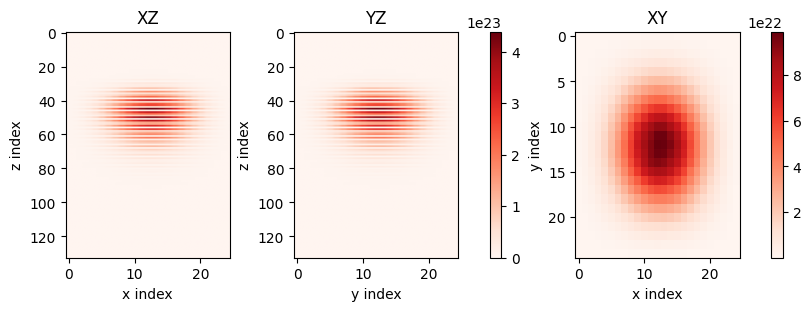

In [12]:
# Sharp vertical profile, so we see the impact of a step on the valley splitting
prof = vp.VerticalProfile(interface_type='sigmoid', top_cap_width_nm=4, bot_cap_width_nm=4)

d2d = d2.Dot2D(si_concentrations=prof.si_concentrations, step_model='none', nx=25, dx_unit_cells=4)
d3model = d3.Dot3D(step_model=d2d, dy_unit_cells=4, ny=25)
lat3d = d3model.generate_random_alloy_lattice()

model_tb = solvers.TwoBand_3D(
    effective_lattice = lat3d, 
    bulk_si_concentration = prof.bot_cap_si_concentration, 
    well_si_concentration = prof.well_si_concentration,
    vertical_field = 0.005,
    dx_nm = d3model.dx_nm,
    dy_nm = d3model.dy_nm
)

evals, evecs = model_tb.solve(n_lowest_eigenstates=2)
v0 = evecs[:,0]
v1 = evecs[:,1]

# Convert vectors v0 and v1 to 2D matrices for viewing
v0 = model_tb.wf_3D_matrix_from_vector(v0)
v1 = model_tb.wf_3D_matrix_from_vector(v1)

# Test normalization
print(f"Norm v0: {np.sum(np.abs(v0)**2 * model_tb.dz * model_tb.dx * model_tb.dy)}")
print(f"Norm v1: {np.sum(np.abs(v1)**2 * model_tb.dz * model_tb.dx * model_tb.dy)}")

# Probability density
density_0 = np.abs(v0)**2
density_1 = np.abs(v1)**2

# Used for plotting
alphas_0 = Normalize(clip=True)(density_0)
alphas_1 = Normalize(clip=True)(density_1)

# Dipolar matrix elements
#x01 = model_tb.x01_nm
#x00 = model_tb.x00_nm
#x11 = model_tb.x11_nm

#z01 = model_tb.z01_nm
#z00 = model_tb.z00_nm
#z11 = model_tb.z11_nm

(nx, ny, nz) = np.shape(density_0)
density_0_xz = np.mean(density_0, axis=1)
density_0_yz = np.mean(density_0, axis=0)
density_0_xy = np.mean(density_0, axis=2)

max_wf = max([np.max(density_0_xz), np.max(density_0_yz), np.max(density_0_xy)])


# Plotting
fig, ax = plt.subplots(1, 3, figsize=(8,3), layout='constrained')

im0 = ax[0].imshow(density_0_xz.T, cmap="Reds",  vmin=0, vmax=max_wf, aspect='auto')
ax[0].set_title('XZ')

im1 = ax[1].imshow(density_0_yz.T, cmap="Reds",  vmin=0, vmax=max_wf, aspect='auto')
fig.colorbar(im1, ax=ax[1])
ax[1].set_title('YZ')

im2 = ax[2].imshow(density_0_xy.T, cmap="Reds", aspect='auto')
fig.colorbar(im2, ax=ax[2])
ax[2].set_title('XY')

"""
ax[0].text(0.05, 0.26, r"$\langle v_0 | x | v_0 \rangle = $" + f"{x00:0.2f} (nm)", transform=ax[0].transAxes)
ax[0].text(0.05, 0.33, r"$\langle v_1 | x | v_1 \rangle = $" + f"{x11:0.2f} (nm)", transform=ax[0].transAxes)
ax[0].text(0.05, 0.4, r"$\langle v_0 | x | v_1 \rangle = $" + f"{x01:0.2f} (nm)", transform=ax[0].transAxes)

ax[1].text(0.05, 0.26, r"$\langle v_0 | z | v_0 \rangle = $" + f"{z00:0.2f} (nm)", transform=ax[1].transAxes)
ax[1].text(0.05, 0.33, r"$\langle v_1 | z | v_1 \rangle = $" + f"{z11:0.2f} (nm)", transform=ax[1].transAxes)
ax[1].text(0.05, 0.4, r"$\langle v_0 | z | v_1 \rangle = $" + f"{z01:0.2f} (nm)", transform=ax[1].transAxes)
"""

ax[0].set_xlabel("x index")
ax[0].set_ylabel("z index")

ax[1].set_xlabel("y index")
ax[1].set_ylabel("z index")

ax[2].set_xlabel("x index")
ax[2].set_ylabel("y index")

plt.show()

